# Outlier Filtering for Cool Dwarf Color-logg Relationships

This notebook implements outlier detection and filtering for the cross-matched Gaia-LAMOST-LAMOST_vac dataset.

**Approach Summary:**
- Use absolute magnitude colors (intrinsic stellar properties)
- 0.1 dex logg bins
- **Iterative sigma clipping (astropy) per bin with median centrality**
- **Remove stars flagged in ≥1 colors (strict quality control)**

In [1]:
import pandas as pd

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.stats import sigma_clip
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define paths using Path for cross-platform compatibility
DATA_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\Xmatch_result')
NOTEBOOKS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\notebooks')
RESULTS_DIR = Path(r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\results')

# Create results directory if it doesn't exist
RESULTS_DIR.mkdir(exist_ok=True)

## Phase 1: Load and Inspect Dataset

Load the cross-matched dataset and verify its structure.

In [3]:
# Load the cross-matched dataset
input_path = DATA_DIR / 'Xmatch_gaia_LAMOST_LAMOSTvac_F_dwarf.csv'
df = pd.read_csv(input_path)

print(f"Dataset loaded: {len(df)} rows, {len(df.columns)} columns")

# Pre-processing: Standardize to one set of Gaia magnitudes to avoid recomputing colors
print(f"Initial columns: {len(df.columns)}")
# Drop apparent Gaia magnitudes as absolute ones are available and preferred for intrinsic properties
df.drop(columns=['Gmag', 'BPmag', 'RPmag'], inplace=True, errors='ignore')
print(f"Columns after dropping apparent Gaia mags: {len(df.columns)}")

# Convert Pan-STARRS apparent magnitudes to absolute magnitudes
# Formula: M = m - 5 * log10(d) + 5
ps_mags = ['mag_ps_g', 'mag_ps_r', 'mag_ps_i', 'mag_ps_z', 'mag_ps_y']
for mag in ps_mags:
    if mag in df.columns and 'distance_gaia_pc' in df.columns:
        abs_mag_name = mag.replace('mag_ps_', 'A_ps_')
        df[abs_mag_name] = df[mag] - 5 * np.log10(df['distance_gaia_pc']) + 5
        df.drop(columns=[mag], inplace=True)
        print(f"Converted {mag} to {abs_mag_name}")

print("\nColumns:", df.columns.tolist())
print(f"\nlogg range: {df['logg'].min():.2f} - {df['logg'].max():.2f}")
print(f"logg mean: {df['logg'].mean():.2f}, median: {df['logg'].median():.2f}")

Dataset loaded: 485324 rows, 28 columns
Initial columns: 28
Columns after dropping apparent Gaia mags: 25
Converted mag_ps_g to A_ps_g
Converted mag_ps_r to A_ps_r
Converted mag_ps_i to A_ps_i
Converted mag_ps_z to A_ps_z
Converted mag_ps_y to A_ps_y

Columns: ['obsid', 'subclass', 'gaia_source_id', 'distance_gaia_pc', 'teff', 'logg', 'A_GG', 'A_BP', 'A_RP', 'A_J', 'A_H', 'A_KS', 'A_W1', 'A_W2', 'A_BAP', 'A_VAP', 'A_RAP', 'A_GSD', 'A_RSD', 'A_ISD', 'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y']

logg range: 0.26 - 4.90
logg mean: 4.13, median: 4.15


In [4]:
df.head()

,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,A_VAP,A_RAP,A_GSD,A_RSD,A_ISD,A_ps_g,A_ps_r,A_ps_i,A_ps_z,A_ps_y
0,299910242,F9,218253058432384,2584.595848,5621.05,4.387,5.323396,5.064098,4.463838,3.825463,...,5.169063,4.647720,5.565353,4.692234,5.540123,5.039336,4.560637,4.358437,4.285037,4.221738
1,300003054,F0,279692565863680,1197.577725,6512.09,4.105,2.743019,2.867387,2.300888,1.901812,...,2.788042,2.650095,3.206625,2.893011,2.978450,2.858481,2.630482,2.583482,2.602482,2.628081
2,483006140,F0,279692565863680,1197.577725,6549.88,4.120,2.760979,2.956954,2.396033,2.025593,...,2.985425,2.842096,3.244993,2.873903,2.764101,2.858481,2.630482,2.583482,2.602482,2.628081
3,300014173,F6,492516785395968,592.602005,6131.14,4.276,3.921653,4.337359,3.612836,3.213820,...,3.949214,3.862582,4.296018,3.987487,4.097969,4.766985,4.365185,4.255185,4.215984,4.188684
4,483006043,F7,492516785395968,592.602005,6123.43,4.270,4.277970,4.636078,3.953510,3.403232,...,4.525322,4.314869,4.767911,4.385202,4.166126,4.766985,4.365185,4.255185,4.215984,4.188684


In [5]:
# Basic data quality check
print("Missing values summary:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

# Filter to reasonable logg range for dwarfs
logg_min, logg_max = 3.5, 5.8
df = df[(df['logg'] >= logg_min) & (df['logg'] <= logg_max)]
print(f"\nAfter logg range filtering: {len(df)} stars")

Missing values summary:
Series([], dtype: int64)

After logg range filtering: 475607 stars


## Phase 2: Create Color Indices

Create color indices from all 21 distinct magnitudes for physics-based intrinsic properties.

In [6]:
# Define ALL 21 distinct magnitudes (after dropping apparent Gaia mags)
# Survey breakdown:
# - Gaia absolute (3): A_GG, A_BP, A_RP
# - Pan-STARRS (5): A_ps_g, A_ps_r, A_ps_i, A_ps_z, A_ps_y
# - 2MASS (3): A_J, A_H, A_KS
# - WISE (2): A_W1, A_W2
# - APASS (3): A_BAP, A_VAP, A_RAP
# - SDSS (5): A_GSD, A_RSD, A_ISD (note: only 3 SDSS mags in this dataset)
# Total: 3+5+3+2+3+3 = 19 distinct magnitude bands used

all_magnitudes = [
    # Gaia absolute magnitudes
    'A_GG', 'A_BP', 'A_RP',
    # Pan-STARRS
    'A_ps_g', 'A_ps_r', 'A_ps_i', 'A_ps_z', 'A_ps_y',
    # 2MASS
    'A_J', 'A_H', 'A_KS',
    # WISE
    'A_W1', 'A_W2',
    # APASS
    'A_BAP', 'A_VAP', 'A_RAP',
    # SDSS
    'A_GSD', 'A_RSD', 'A_ISD'
]

# Check which magnitudes are actually in the dataframe
available_mags = [m for m in all_magnitudes if m in df.columns]
missing_mags = [m for m in all_magnitudes if m not in df.columns]

print(f"Expected magnitudes: {len(all_magnitudes)}")
print(f"Available magnitudes: {len(available_mags)}")
if missing_mags:
    print(f"Missing magnitudes: {missing_mags}")
else:
    print("All expected magnitudes are present!")

# Define sorted magnitudes from shortest to longest effective wavelength
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP', 
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H', 
    'A_KS', 'A_W1', 'A_W2'
]

# Generate all 171 possible color combinations (shorter - longer wavelength)
color_combinations = {}
for i in range(len(sorted_mags)):
    for j in range(i + 1, len(sorted_mags)):
        mag1 = sorted_mags[i]
        mag2 = sorted_mags[j]
        color_name = f'COLOR_{mag1}_{mag2}'
        color_combinations[color_name] = (mag1, mag2)

# Verify all magnitudes are used in at least one color
mags_used = set()
for color_name, (mag1, mag2) in color_combinations.items():
    mags_used.add(mag1)
    mags_used.add(mag2)

mags_not_used = set(available_mags) - mags_used
if mags_not_used:
    print(f"\nWARNING: These magnitudes are NOT used in any color: {mags_not_used}")
else:
    print(f"\n✓ All {len(mags_used)} available magnitudes are used in color combinations")

# Create color columns
for color_name, (mag1, mag2) in color_combinations.items():
    if mag1 in df.columns and mag2 in df.columns:
        df[color_name] = df[mag1] - df[mag2]
    else:
        print(f"WARNING: Cannot create {color_name}, missing column(s)")

print(f"\nCreated {len(color_combinations)} color indices.")
# Print first 5 and last 5 as examples
color_names = list(color_combinations.keys())
print("Examples:")
for name in color_names[:5] + ["..."] + color_names[-5:]:
    if name == "...":
        print("  ...")
    else:
        m1, m2 = color_combinations[name]
        print(f"  {name}: {m1} - {m2}")

Expected magnitudes: 19
Available magnitudes: 19
All expected magnitudes are present!

✓ All 19 available magnitudes are used in color combinations

Created 171 color indices.
Examples:
  COLOR_A_BAP_A_GSD: A_BAP - A_GSD
  COLOR_A_BAP_A_ps_g: A_BAP - A_ps_g
  COLOR_A_BAP_A_BP: A_BAP - A_BP
  COLOR_A_BAP_A_VAP: A_BAP - A_VAP
  COLOR_A_BAP_A_ps_r: A_BAP - A_ps_r
  ...
  COLOR_A_H_A_W1: A_H - A_W1
  COLOR_A_H_A_W2: A_H - A_W2
  COLOR_A_KS_A_W1: A_KS - A_W1
  COLOR_A_KS_A_W2: A_KS - A_W2
  COLOR_A_W1_A_W2: A_W1 - A_W2


## Phase 3: logg Binning

Define logg bins with fixed width (0.1 dex) ensuring adequate samples per bin.

In [7]:
"""# OLD CODE (adaptive equal-count bins) — superseded by active fixed-width logg binning cell below
# Create Adaptive logg bins (Equal star counts)
num_bins = 20
# Use qcut to calculate bin edges that divide the data into equal counts
_, logg_bins = pd.qcut(df['logg'], q=num_bins, retbins=True)

# Add bin column to dataframe
# include_lowest=True ensures the minimum value is covered
df['logg_bin'] = pd.cut(df['logg'], logg_bins, include_lowest=True, 
                        labels=[f'{logg_bins[i]:.2f}-{logg_bins[i+1]:.2f}' 
                               for i in range(len(logg_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('logg_bin').agg({
    'logg': ['count', 'min', 'max', 'mean']
}).round(2)

print(f"logg adaptive bin statistics ({num_bins} bins):")
"""

'# OLD CODE (adaptive equal-count bins) — superseded by active fixed-width logg binning cell below\n# Create Adaptive logg bins (Equal star counts)\nnum_bins = 20\n# Use qcut to calculate bin edges that divide the data into equal counts\n_, logg_bins = pd.qcut(df[\'logg\'], q=num_bins, retbins=True)\n\n# Add bin column to dataframe\n# include_lowest=True ensures the minimum value is covered\ndf[\'logg_bin\'] = pd.cut(df[\'logg\'], logg_bins, include_lowest=True, \n                        labels=[f\'{logg_bins[i]:.2f}-{logg_bins[i+1]:.2f}\' \n                               for i in range(len(logg_bins)-1)])\n\n# Check bin statistics\nbin_stats = df.groupby(\'logg_bin\').agg({\n    \'logg\': [\'count\', \'min\', \'max\', \'mean\']\n}).round(2)\n\nprint(f"logg adaptive bin statistics ({num_bins} bins):")\n'

logg bin statistics:
            logg                
           count  min  max  mean
logg_bin                        
3.5-3.6     1960  3.5  3.6  3.55
3.6-3.7     3535  3.6  3.7  3.65
3.7-3.8     7678  3.7  3.8  3.76
3.8-3.9    18050  3.8  3.9  3.86
3.9-4.0    39919  3.9  4.0  3.96
4.0-4.1    89101  4.0  4.1  4.06
4.1-4.2   138863  4.1  4.2  4.15
4.2-4.3   104100  4.2  4.3  4.24
4.3-4.4    43379  4.3  4.4  4.34
4.4-4.5    17695  4.4  4.5  4.44
4.5-4.6     8013  4.5  4.6  4.54
4.6-4.7     2532  4.6  4.7  4.64
4.7-4.8      636  4.7  4.8  4.74
4.8-4.9      146  4.8  4.9  4.84
4.9-5.0        0  NaN  NaN   NaN
5.0-5.1        0  NaN  NaN   NaN
5.1-5.2        0  NaN  NaN   NaN
5.2-5.3        0  NaN  NaN   NaN
5.3-5.4        0  NaN  NaN   NaN
5.4-5.5        0  NaN  NaN   NaN
5.5-5.6        0  NaN  NaN   NaN
5.6-5.7        0  NaN  NaN   NaN
5.7-5.8        0  NaN  NaN   NaN


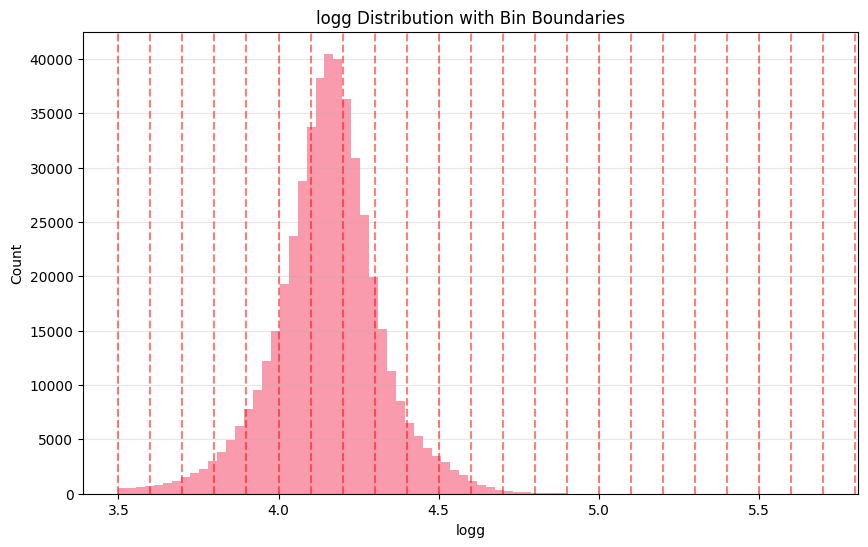

In [8]:
# Create logg bins
bin_width = 0.1  # dex
logg_bins = np.arange(3.5, 5.8 + bin_width, bin_width)

# Add bin column to dataframe
df['logg_bin'] = pd.cut(df['logg'], logg_bins, right=False, 
                        labels=[f'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}' 
                               for i in range(len(logg_bins)-1)])

# Check bin statistics
bin_stats = df.groupby('logg_bin').agg({
    'logg': ['count', 'min', 'max', 'mean']
}).round(2)

print("logg bin statistics:")
print(bin_stats)

# Visualize logg distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
df['logg'].plot.hist(bins=50, ax=ax, alpha=0.7)

# Add vertical lines for bin boundaries
for logg_boundary in logg_bins:
    ax.axvline(logg_boundary, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('logg')
ax.set_ylabel('Count')
ax.set_title('logg Distribution with Bin Boundaries')
ax.grid(True, alpha=0.3)
#plt.savefig(RESULTS_DIR / 'logg_distribution_bins.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4: Outlier Detection (Iterative Sigma Clipping)

Apply iterative sigma clipping using `astropy.stats.sigma_clip` per logg bin for each color index.

In [10]:
def detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None):
    """
    Use astropy's iterative sigma clipping to detect outliers.
    Returns a boolean series where True indicates an outlier.
    """
    values = df_bin[color_name].dropna()
    if len(values) < 10:
        return pd.Series(False, index=df_bin.index)
    
    # Apply sigma clipping
    clipped_data = sigma_clip(values, sigma=sigma, maxiters=maxiters, cenfunc='median', stdfunc='std')
    
    # Identify outliers (values that were clipped/masked)
    # clipped_data is a masked array where masked=True means outlier
    outlier_mask = clipped_data.mask
    
    return pd.Series(outlier_mask, index=values.index)

# Create outlier flags for each color and bin
outlier_columns = []

for color_name in color_combinations.keys():
    outlier_col_name = f'{color_name}_outlier'
    outlier_columns.append(outlier_col_name)
    df[outlier_col_name] = False 
    
    for bin_name, df_bin in df.groupby('logg_bin'):
        outlier_mask = detect_outliers_sigma_clip(df_bin, color_name, sigma=3.0, maxiters=None)
        df.loc[outlier_mask.index, outlier_col_name] = outlier_mask

print(f"Created {len(outlier_columns)} outlier flag columns using iterative sigma clipping")

Created 171 outlier flag columns using iterative sigma clipping


In [11]:
# Convergence Diagnostics and Detailed Statistics
print("=" * 80)
print("=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===")
print("=" * 80)

convergence_stats = {}

for color_name in color_combinations.keys():
    convergence_stats[color_name] = {}
    
    for bin_name, df_bin in df.groupby('logg_bin'):
        values = df_bin[color_name].dropna()
        if len(values) >= 10:
            # Run sigma clipping with 5 iterations
            clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, 
                                   cenfunc='median', stdfunc='std')
            # Run sigma clipping until convergence (maxiters=None)
            clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, 
                                       cenfunc='median', stdfunc='std')
            
            convergence_stats[color_name][bin_name] = {
                'original_N': len(values),
                'after_5_iters_N': int((~clipped_5.mask).sum()),
                'final_N': int((~clipped_final.mask).sum()),
                'removed_5_iters': int(clipped_5.mask.sum()),
                'removed_final': int(clipped_final.mask.sum()),
                'original_median': float(np.median(values)),
                'original_std': float(np.std(values)),
                'final_median': float(np.median(values[~clipped_final.mask])),
                'final_std': float(np.std(values[~clipped_final.mask]))
            }

# Print detailed convergence statistics per color
print("\n=== Per-Color Convergence Summary ===\n")
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    
    print(f"\n{color_name}:")
    print(f"  Total stars: {total_original}")
    print(f"  Removed after 5 iters: {total_removed_5} ({100*total_removed_5/total_original:.3f}%)")
    print(f"  Removed (converged):   {total_removed_final} ({100*total_removed_final/total_original:.3f}%)")
    print(f"  Difference (5 vs converged): {total_removed_final - total_removed_5}")
    
    print(f"  Per-bin breakdown:")
    for bin_name, stats in convergence_stats[color_name].items():
        print(f"    {bin_name}: {stats['original_N']:5d} -> {stats['final_N']:5d} "
              f"(removed: {stats['removed_final']:4d}, "
              f"median: {stats['original_median']:.3f} -> {stats['final_median']:.3f}, "
              f"std: {stats['original_std']:.3f} -> {stats['final_std']:.3f})")

# Create strict consensus outlier flag: outlier if flagged in ANY color (>=1)
df['outlier_consensus'] = df[outlier_columns].any(axis=1)

total_stars = len(df)
outlier_stars = df['outlier_consensus'].sum()
clean_stars = total_stars - outlier_stars

print("\n" + "=" * 80)
print("=== FINAL OUTLIER SUMMARY ===")
print("=" * 80)
print(f"\nTotal stars: {total_stars}")
print(f"Outliers (flagged in ≥1 colors): {outlier_stars} ({100*outlier_stars/total_stars:.2f}%)")
print(f"Clean stars: {clean_stars} ({100*clean_stars/total_stars:.2f}%)")

print("\nSurvival statistics by logg bin:")
bin_survival = df.groupby('logg_bin').agg({
    'obsid': 'count',
    'outlier_consensus': 'sum'
})
bin_survival.columns = ['total', 'outliers']
bin_survival['survival_rate'] = 100 * (1 - bin_survival['outliers']/bin_survival['total'])
print(bin_survival.round(2))

=== DETAILED SIGMA CLIPPING CONVERGENCE STATISTICS ===

=== Per-Color Convergence Summary ===


COLOR_A_BAP_A_GSD:
  Total stars: 475607
  Removed after 5 iters: 29919 (6.291%)
  Removed (converged):   36105 (7.591%)
  Difference (5 vs converged): 6186
  Per-bin breakdown:
    3.5-3.6:  1960 ->  1804 (removed:  156, median: 0.313 -> 0.271, std: 8.745 -> 0.508)
    3.6-3.7:  3535 ->  3263 (removed:  272, median: 0.309 -> 0.277, std: 27.847 -> 0.493)
    3.7-3.8:  7678 ->  7065 (removed:  613, median: 0.298 -> 0.269, std: 8.372 -> 0.451)
    3.8-3.9: 18050 -> 16633 (removed: 1417, median: 0.269 -> 0.247, std: 6.213 -> 0.392)
    3.9-4.0: 39919 -> 36790 (removed: 3129, median: 0.246 -> 0.224, std: 5.619 -> 0.363)
    4.0-4.1: 89101 -> 82521 (removed: 6580, median: 0.225 -> 0.207, std: 11.796 -> 0.339)
    4.1-4.2: 138863 -> 128713 (removed: 10150, median: 0.217 -> 0.201, std: 57.347 -> 0.314)
    4.2-4.3: 104100 -> 96284 (removed: 7816, median: 0.229 -> 0.212, std: 28.141 -> 0.324)
    4.

## Phase 5: Diagnostic Plots (Comparison of Filtering Iterations)

Compare the sigma clipping effect at different iteration stages:
1. **Initial**: Raw data before any sigma clipping
2. **After 5 iterations**: Standard astropy default
3. **Final (Converged)**: After maxiters=None (iterate until no more outliers)

This visualization helps verify the method is working correctly and shows how much additional cleaning the full convergence provides.

=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===


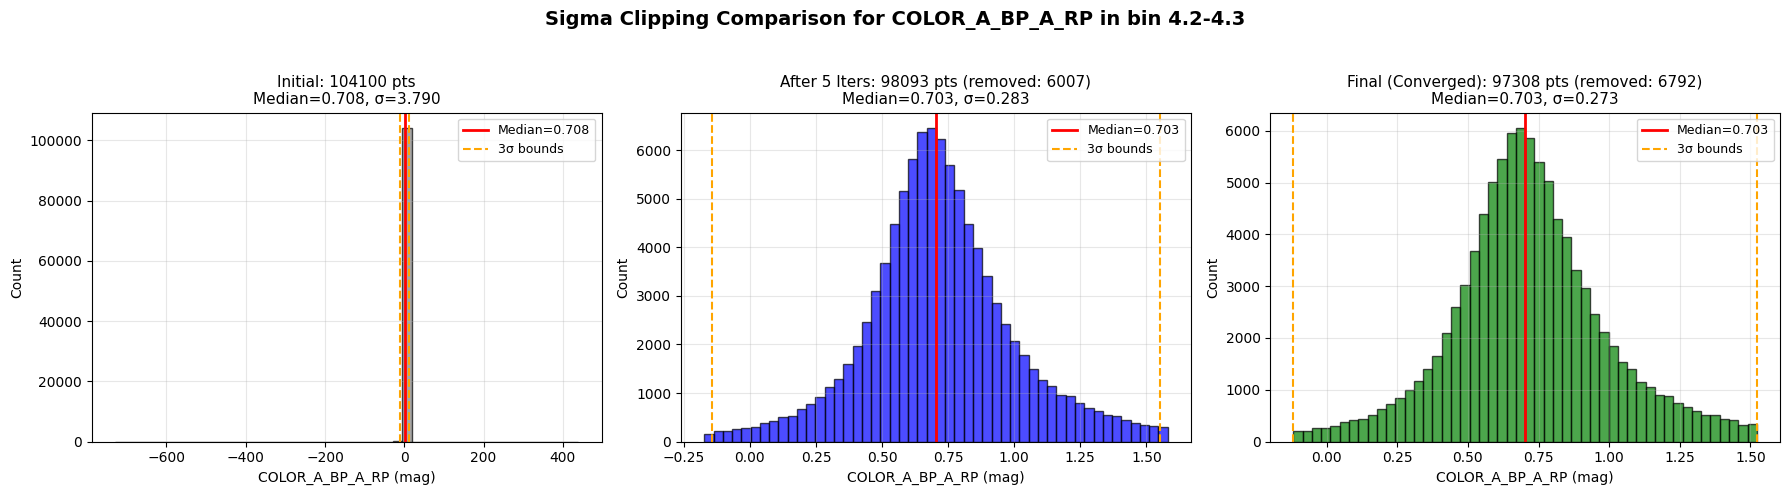


COLOR_A_BP_A_RP in 4.2-4.3:
  Initial:     104100 pts, median=0.7080, std=3.7903
  After 5 its: 98093 pts, median=0.7033, std=0.2825, removed=6007
  Final:       97308 pts, median=0.7027, std=0.2733, removed=6792
  Difference (5 iters vs converged): 785 additional pts removed


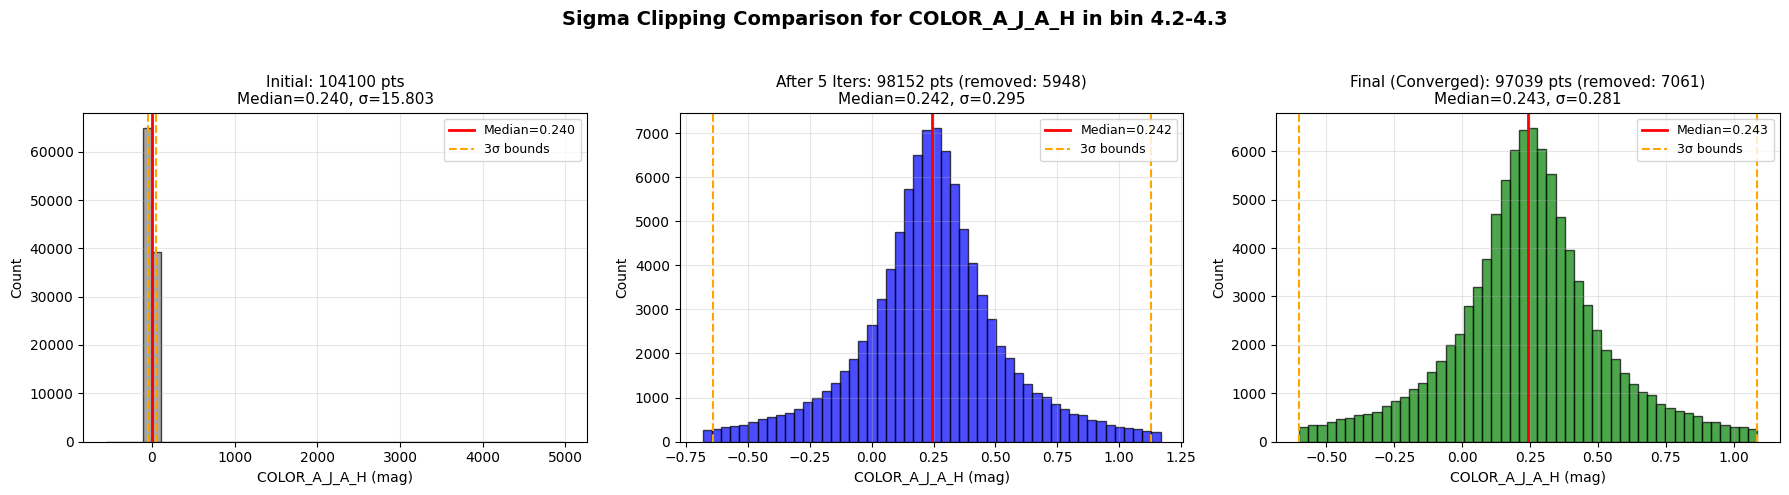


COLOR_A_J_A_H in 4.2-4.3:
  Initial:     104100 pts, median=0.2403, std=15.8034
  After 5 its: 98152 pts, median=0.2425, std=0.2950, removed=5948
  Final:       97039 pts, median=0.2427, std=0.2812, removed=7061
  Difference (5 iters vs converged): 1113 additional pts removed


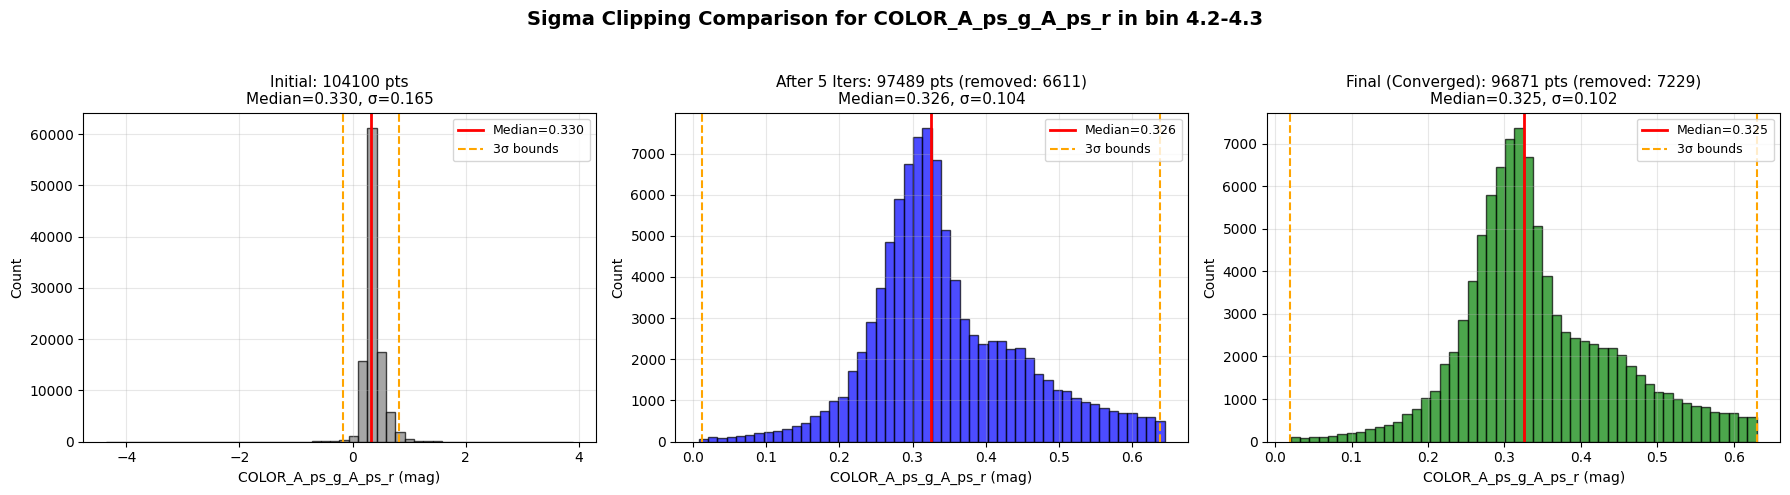


COLOR_A_ps_g_A_ps_r in 4.2-4.3:
  Initial:     104100 pts, median=0.3300, std=0.1648
  After 5 its: 97489 pts, median=0.3256, std=0.1041, removed=6611
  Final:       96871 pts, median=0.3251, std=0.1017, removed=7229
  Difference (5 iters vs converged): 618 additional pts removed


In [12]:
# Comparison visualization: Initial vs 5 iterations vs Final (converged)
def compare_clipping_iterations(df, color_name, bin_name):
    """
    Compare the effect of sigma clipping at different iteration stages.
    Shows: (1) Initial, (2) After 5 iterations, (3) Final converged result.
    """
    df_bin = df[df['logg_bin'] == bin_name]
    values = df_bin[color_name].dropna()
    
    if len(values) < 10:
        print(f"Not enough data points in bin {bin_name} for {color_name}")
        return
    
    # 1. Initial (no clipping)
    initial_median = np.median(values)
    initial_std = np.std(values)
    
    # 2. After 5 iterations
    clipped_5 = sigma_clip(values, sigma=3.0, maxiters=5, cenfunc='median', stdfunc='std')
    values_5 = values[~clipped_5.mask]
    median_5 = np.median(values_5)
    std_5 = np.std(values_5)
    
    # 3. Final (None iterations = until convergence)
    clipped_final = sigma_clip(values, sigma=3.0, maxiters=None, cenfunc='median', stdfunc='std')
    values_final = values[~clipped_final.mask]
    median_final = np.median(values_final)
    std_final = np.std(values_final)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Initial
    ax1 = axes[0]
    ax1.hist(values, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax1.axvline(initial_median, color='red', linewidth=2, label=f'Median={initial_median:.3f}')
    ax1.axvline(initial_median - 3*initial_std, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax1.axvline(initial_median + 3*initial_std, color='orange', linestyle='--', linewidth=1.5)
    ax1.set_title(f'Initial: {len(values)} pts\nMedian={initial_median:.3f}, σ={initial_std:.3f}', fontsize=11)
    ax1.set_xlabel(f'{color_name} (mag)')
    ax1.set_ylabel('Count')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: After 5 iterations
    ax2 = axes[1]
    ax2.hist(values_5, bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax2.axvline(median_5, color='red', linewidth=2, label=f'Median={median_5:.3f}')
    ax2.axvline(median_5 - 3*std_5, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax2.axvline(median_5 + 3*std_5, color='orange', linestyle='--', linewidth=1.5)
    removed_5 = len(values) - len(values_5)
    ax2.set_title(f'After 5 Iters: {len(values_5)} pts (removed: {removed_5})\nMedian={median_5:.3f}, σ={std_5:.3f}', fontsize=11)
    ax2.set_xlabel(f'{color_name} (mag)')
    ax2.set_ylabel('Count')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Final (converged)
    ax3 = axes[2]
    ax3.hist(values_final, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax3.axvline(median_final, color='red', linewidth=2, label=f'Median={median_final:.3f}')
    ax3.axvline(median_final - 3*std_final, color='orange', linestyle='--', linewidth=1.5, label=f'3σ bounds')
    ax3.axvline(median_final + 3*std_final, color='orange', linestyle='--', linewidth=1.5)
    removed_final = len(values) - len(values_final)
    ax3.set_title(f'Final (Converged): {len(values_final)} pts (removed: {removed_final})\nMedian={median_final:.3f}, σ={std_final:.3f}', fontsize=11)
    ax3.set_xlabel(f'{color_name} (mag)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sigma Clipping Comparison for {color_name} in bin {bin_name}', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clipping_comparison_{color_name}_{bin_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print(f"\n{color_name} in {bin_name}:")
    print(f"  Initial:     {len(values):5d} pts, median={initial_median:.4f}, std={initial_std:.4f}")
    print(f"  After 5 its: {len(values_5):5d} pts, median={median_5:.4f}, std={std_5:.4f}, removed={removed_5}")
    print(f"  Final:       {len(values_final):5d} pts, median={median_final:.4f}, std={std_final:.4f}, removed={removed_final}")
    print(f"  Difference (5 iters vs converged): {removed_final - removed_5} additional pts removed")

# Show comparison for representative colors and bins
print("=" * 80)
print("=== COMPARISON VISUALIZATIONS: Initial vs 5 Iters vs Converged ===")
print("=" * 80)

# Get middle bin for representative comparison
logg_bins_available = sorted(df['logg_bin'].dropna().unique())
middle_bin_idx = len(logg_bins_available) // 2
representative_bin = logg_bins_available[middle_bin_idx]

# Show comparisons for a few representative colors
representative_colors = ['COLOR_A_BP_A_RP', 'COLOR_A_J_A_H', 'COLOR_A_ps_g_A_ps_r']
for color in representative_colors:
    if color in color_combinations:
        compare_clipping_iterations(df, color, representative_bin)

In [13]:
# Summary table: Compare 5 iterations vs converged across ALL colors
print("\n" + "=" * 80)
print("=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===")
print("=" * 80)

summary_data = []
for color_name in color_combinations.keys():
    total_original = sum(s['original_N'] for s in convergence_stats[color_name].values())
    total_removed_5 = sum(s['removed_5_iters'] for s in convergence_stats[color_name].values())
    total_removed_final = sum(s['removed_final'] for s in convergence_stats[color_name].values())
    diff = total_removed_final - total_removed_5
    
    summary_data.append({
        'Color': color_name,
        'Total': total_original,
        'Removed (5 iters)': total_removed_5,
        'Removed (converged)': total_removed_final,
        'Extra removed': diff,
        '% Removed (5 iters)': f"{100*total_removed_5/total_original:.2f}%",
        '% Removed (converged)': f"{100*total_removed_final/total_original:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Overall summary
total_original_all = sum(s['Total'] for s in summary_data)
total_removed_5_all = sum(s['Removed (5 iters)'] for s in summary_data)
total_removed_final_all = sum(s['Removed (converged)'] for s in summary_data)

print(f"\n--- Overall (summed across all colors) ---")
print(f"Total data points (all colors combined): {total_original_all}")
print(f"Total removed after 5 iterations: {total_removed_5_all}")
print(f"Total removed after convergence: {total_removed_final_all}")
print(f"Additional removed by convergence: {total_removed_final_all - total_removed_5_all}")


=== SUMMARY: 5 Iterations vs Full Convergence (All Colors) ===
              Color  Total  Removed (5 iters)  Removed (converged)  Extra removed % Removed (5 iters) % Removed (converged)
  COLOR_A_BAP_A_GSD 475607              29919                36105           6186               6.29%                 7.59%
 COLOR_A_BAP_A_ps_g 475607              18319                19935           1616               3.85%                 4.19%
   COLOR_A_BAP_A_BP 475607              25048                29035           3987               5.27%                 6.10%
  COLOR_A_BAP_A_VAP 475607              24269                28093           3824               5.10%                 5.91%
 COLOR_A_BAP_A_ps_r 475607              18963                20644           1681               3.99%                 4.34%
  COLOR_A_BAP_A_RSD 475607              23253                26315           3062               4.89%                 5.53%
  COLOR_A_BAP_A_RAP 475607              21652                24342  

## Phase 6: Save Filtered Dataset

Create clean dataset and save.

In [14]:
df_clean = df[~df['outlier_consensus']].copy()
df_outliers = df[df['outlier_consensus']].copy()

cols_to_drop = outlier_columns + ['logg_bin', 'outlier_consensus']
df_clean_out = df_clean.drop(columns=cols_to_drop, errors='ignore')

clean_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_F_dwarfs_logg_clean.csv'
df_clean_out.to_csv(clean_path, index=False)

print(f"Clean dataset saved: {len(df_clean_out)} stars -> {clean_path}")

Clean dataset saved: 274831 stars -> C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_F_dwarfs_logg_clean.csv


## Phase 7: Sanity Check For Cleaned Dataset

Using the cleaned dataset (after outlier removal), generate comprehensive visualization for:
1. Color distributions plots (ALL colors)
2. ALL color vs logg plots without outliers
3. Bin-wise plots for ALL colors (detailed distributions per logg bin)

In [15]:
# Load the cleaned dataset for comprehensive visualization
clean_data_path = r'C:\git_repo\cool-dwarf_stellar_parameter_inference_from_survey_data\data\outlier_filtering_results\Xmatch_gaia_LAMOST_LAMOSTvac_F_dwarfs_logg_clean.csv'

df_clean_viz = pd.read_csv(clean_data_path)

print(f"Cleaned dataset loaded for viz: {len(df_clean_viz)} stars")

for color_name, (mag1, mag2) in color_combinations.items():
    df_clean_viz[color_name] = df_clean_viz[mag1] - df_clean_viz[mag2]

# Apply the same bins (using edges calculated in Phase 3)
df_clean_viz['logg_bin'] = pd.cut(
    df_clean_viz['logg'], logg_bins, include_lowest=True,
    labels=[f'{logg_bins[i]:.1f}-{logg_bins[i+1]:.1f}' for i in range(len(logg_bins)-1)]
)

Cleaned dataset loaded for viz: 274831 stars


In [16]:
df_clean_viz.columns.tolist()

['obsid',
 'subclass',
 'gaia_source_id',
 'distance_gaia_pc',
 'teff',
 'logg',
 'A_GG',
 'A_BP',
 'A_RP',
 'A_J',
 'A_H',
 'A_KS',
 'A_W1',
 'A_W2',
 'A_BAP',
 'A_VAP',
 'A_RAP',
 'A_GSD',
 'A_RSD',
 'A_ISD',
 'A_ps_g',
 'A_ps_r',
 'A_ps_i',
 'A_ps_z',
 'A_ps_y',
 'COLOR_A_BAP_A_GSD',
 'COLOR_A_BAP_A_ps_g',
 'COLOR_A_BAP_A_BP',
 'COLOR_A_BAP_A_VAP',
 'COLOR_A_BAP_A_ps_r',
 'COLOR_A_BAP_A_RSD',
 'COLOR_A_BAP_A_RAP',
 'COLOR_A_BAP_A_GG',
 'COLOR_A_BAP_A_ps_i',
 'COLOR_A_BAP_A_ISD',
 'COLOR_A_BAP_A_RP',
 'COLOR_A_BAP_A_ps_z',
 'COLOR_A_BAP_A_ps_y',
 'COLOR_A_BAP_A_J',
 'COLOR_A_BAP_A_H',
 'COLOR_A_BAP_A_KS',
 'COLOR_A_BAP_A_W1',
 'COLOR_A_BAP_A_W2',
 'COLOR_A_GSD_A_ps_g',
 'COLOR_A_GSD_A_BP',
 'COLOR_A_GSD_A_VAP',
 'COLOR_A_GSD_A_ps_r',
 'COLOR_A_GSD_A_RSD',
 'COLOR_A_GSD_A_RAP',
 'COLOR_A_GSD_A_GG',
 'COLOR_A_GSD_A_ps_i',
 'COLOR_A_GSD_A_ISD',
 'COLOR_A_GSD_A_RP',
 'COLOR_A_GSD_A_ps_z',
 'COLOR_A_GSD_A_ps_y',
 'COLOR_A_GSD_A_J',
 'COLOR_A_GSD_A_H',
 'COLOR_A_GSD_A_KS',
 'COLOR_A_GSD_A_

In [17]:
df_clean_viz.head()

,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,COLOR_A_J_A_KS,COLOR_A_J_A_W1,COLOR_A_J_A_W2,COLOR_A_H_A_KS,COLOR_A_H_A_W1,COLOR_A_H_A_W2,COLOR_A_KS_A_W1,COLOR_A_KS_A_W2,COLOR_A_W1_A_W2,logg_bin
0,300003054,F0,279692565863680,1197.577725,6512.09,4.105,2.743019,2.867387,2.300888,1.901812,...,0.222598,0.332229,0.241461,-0.019114,0.090517,-0.000251,0.109631,0.018863,-0.090768,4.1-4.2
1,483006140,F0,279692565863680,1197.577725,6549.88,4.120,2.760979,2.956954,2.396033,2.025593,...,0.306546,0.421578,0.381074,0.029463,0.144495,0.103991,0.115032,0.074528,-0.040504,4.1-4.2
2,300014173,F6,492516785395968,592.602005,6131.14,4.276,3.921653,4.337359,3.612836,3.213820,...,0.498134,0.472155,0.377120,0.083556,0.057577,-0.037458,-0.025979,-0.121015,-0.095035,4.2-4.3
3,483006043,F7,492516785395968,592.602005,6123.43,4.270,4.277970,4.636078,3.953510,3.403232,...,0.350874,0.253590,0.357602,0.138743,0.041460,0.145472,-0.097284,0.006728,0.104012,4.2-4.3
4,757516200,F6,617139556505856,1350.264165,6129.88,4.306,3.702365,4.764616,3.579519,3.170527,...,0.012281,0.255204,0.850975,-0.714439,-0.471516,0.124255,0.242923,0.838694,0.595771,4.3-4.4


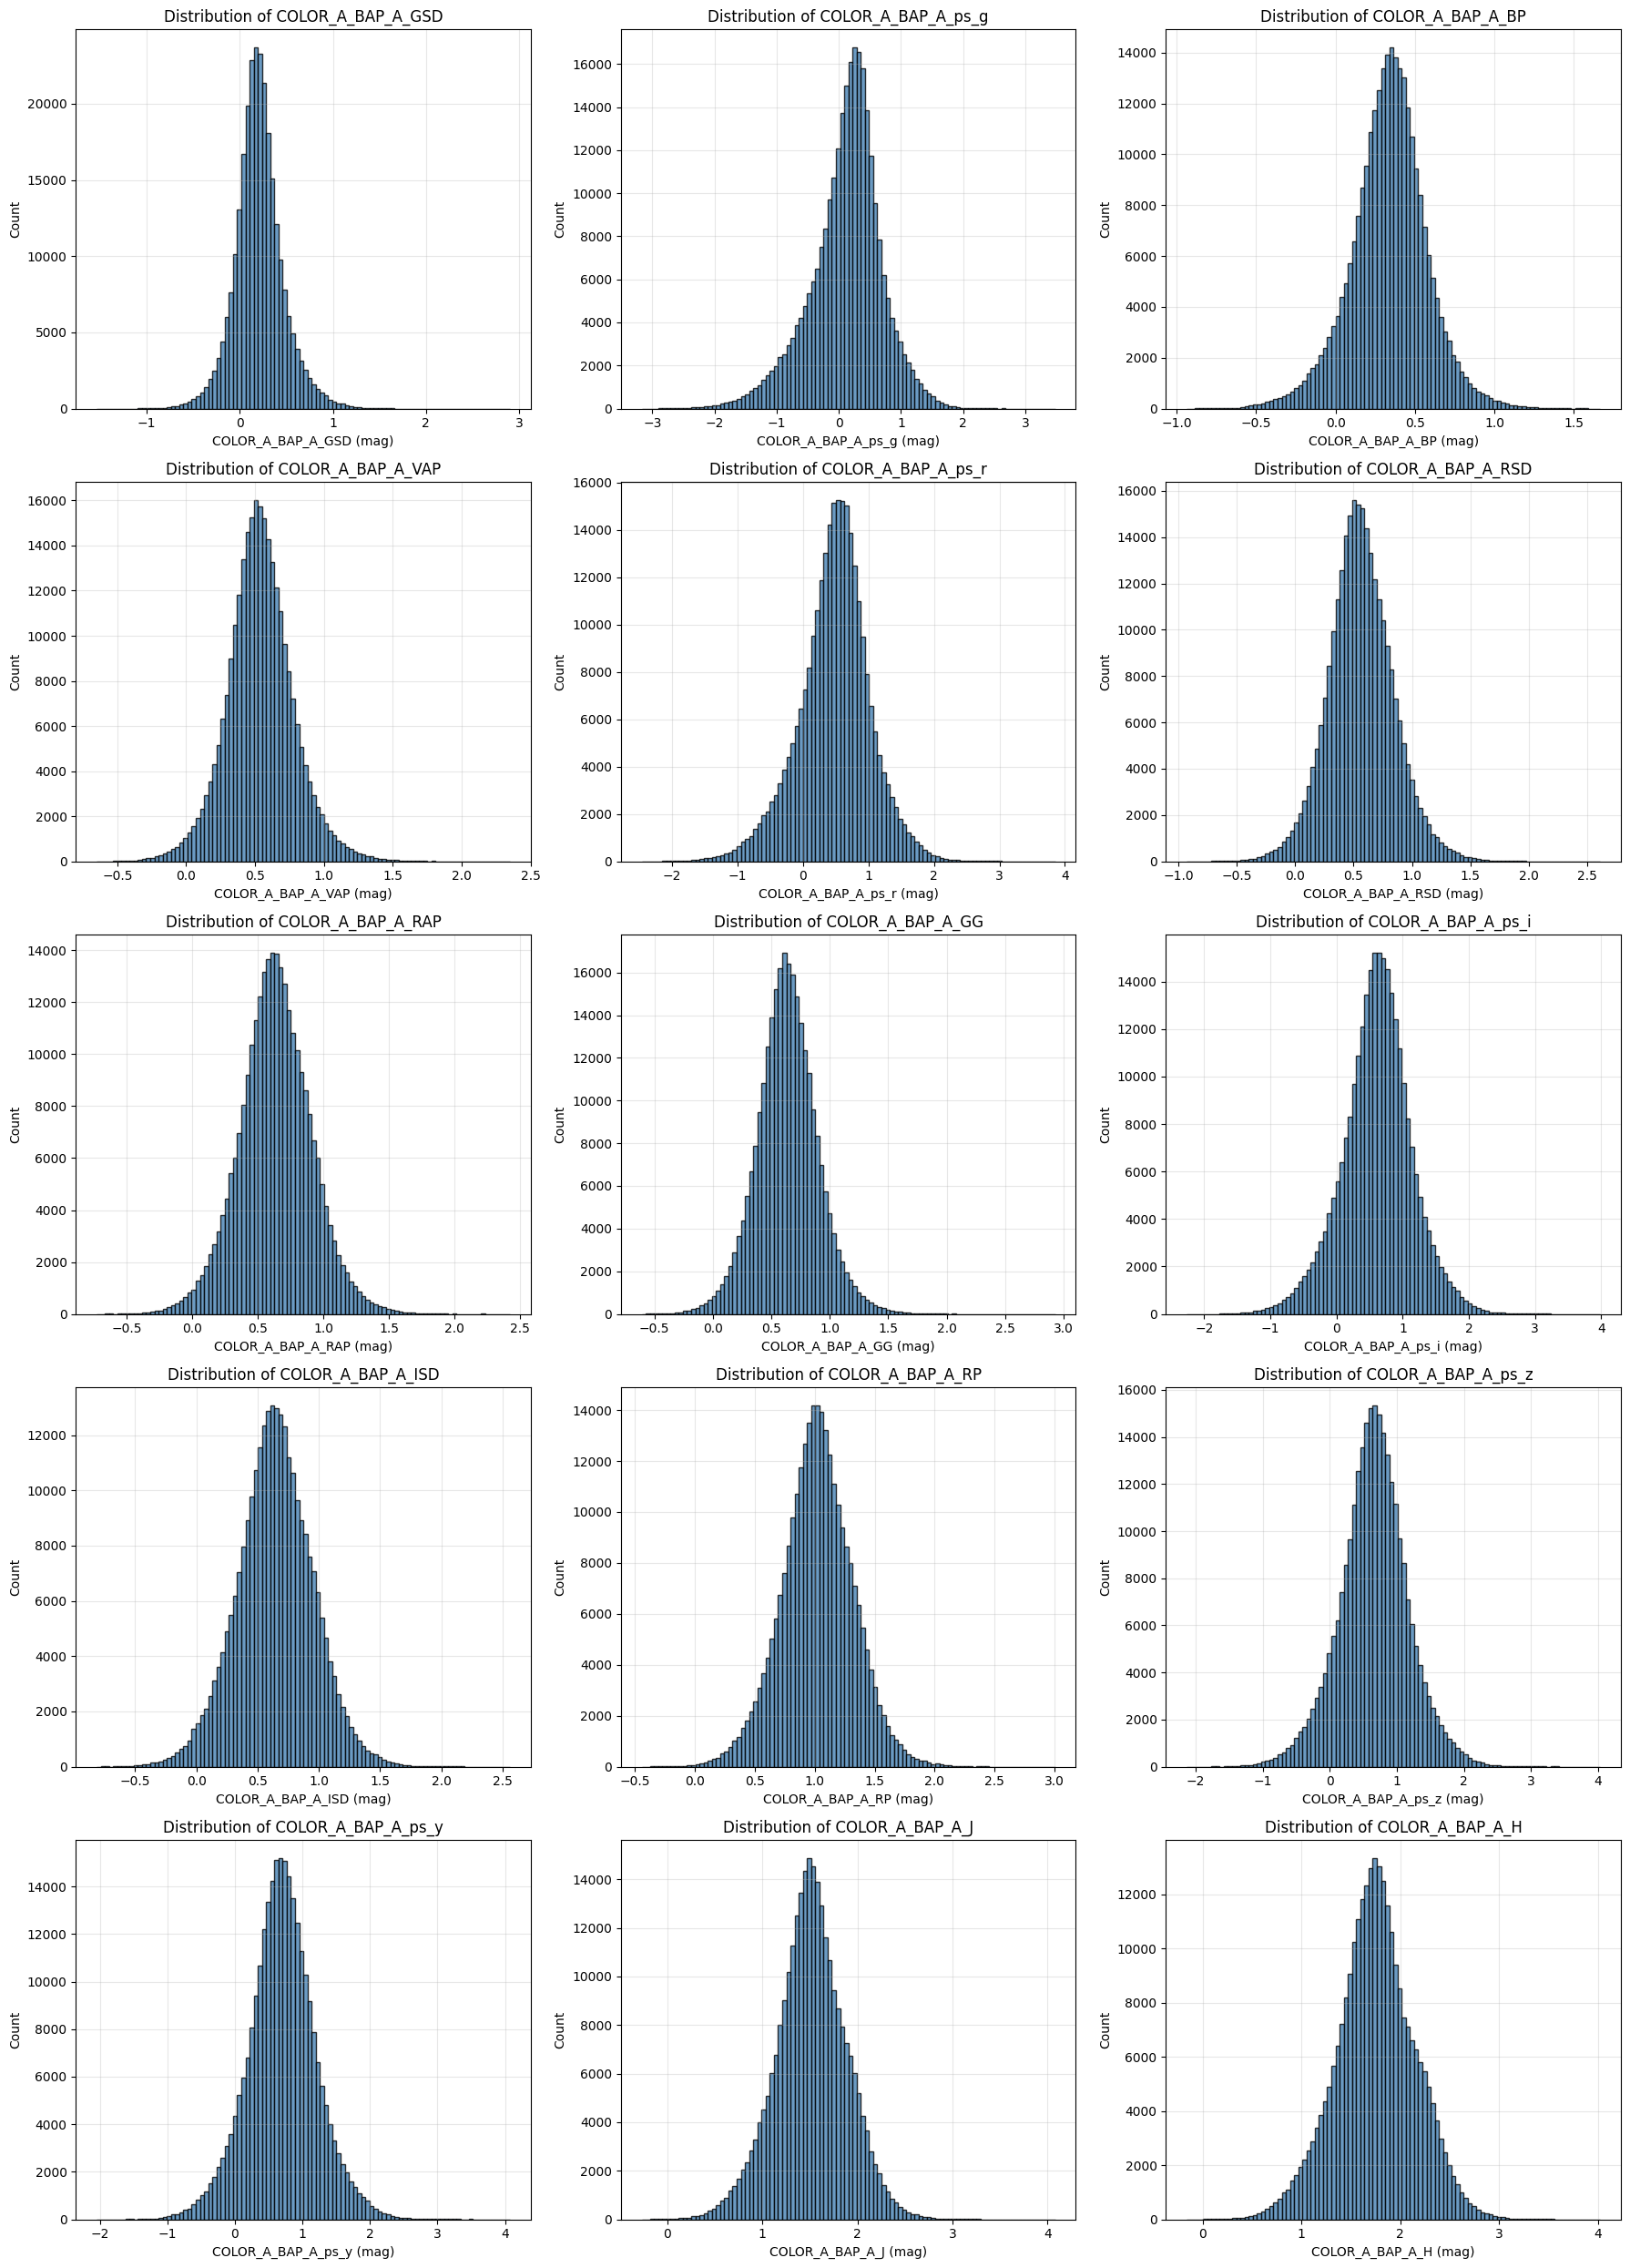

In [18]:
# 1. Color distribution plots for ALL colors (6x3 grid for 17 colors)
# Select a subset of colors to plot to avoid massive plots (e.g., 15 representative colors)
representative_colors = list(color_combinations.keys())[:15]
n_colors = len(representative_colors)
n_cols = 3
n_rows = (n_colors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    df_clean_viz[color_name].plot.hist(bins=100, ax=ax, alpha=0.8, color='steelblue', edgecolor='black')
    ax.set_xlabel(f'{color_name} (mag)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {color_name}')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_color_distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()

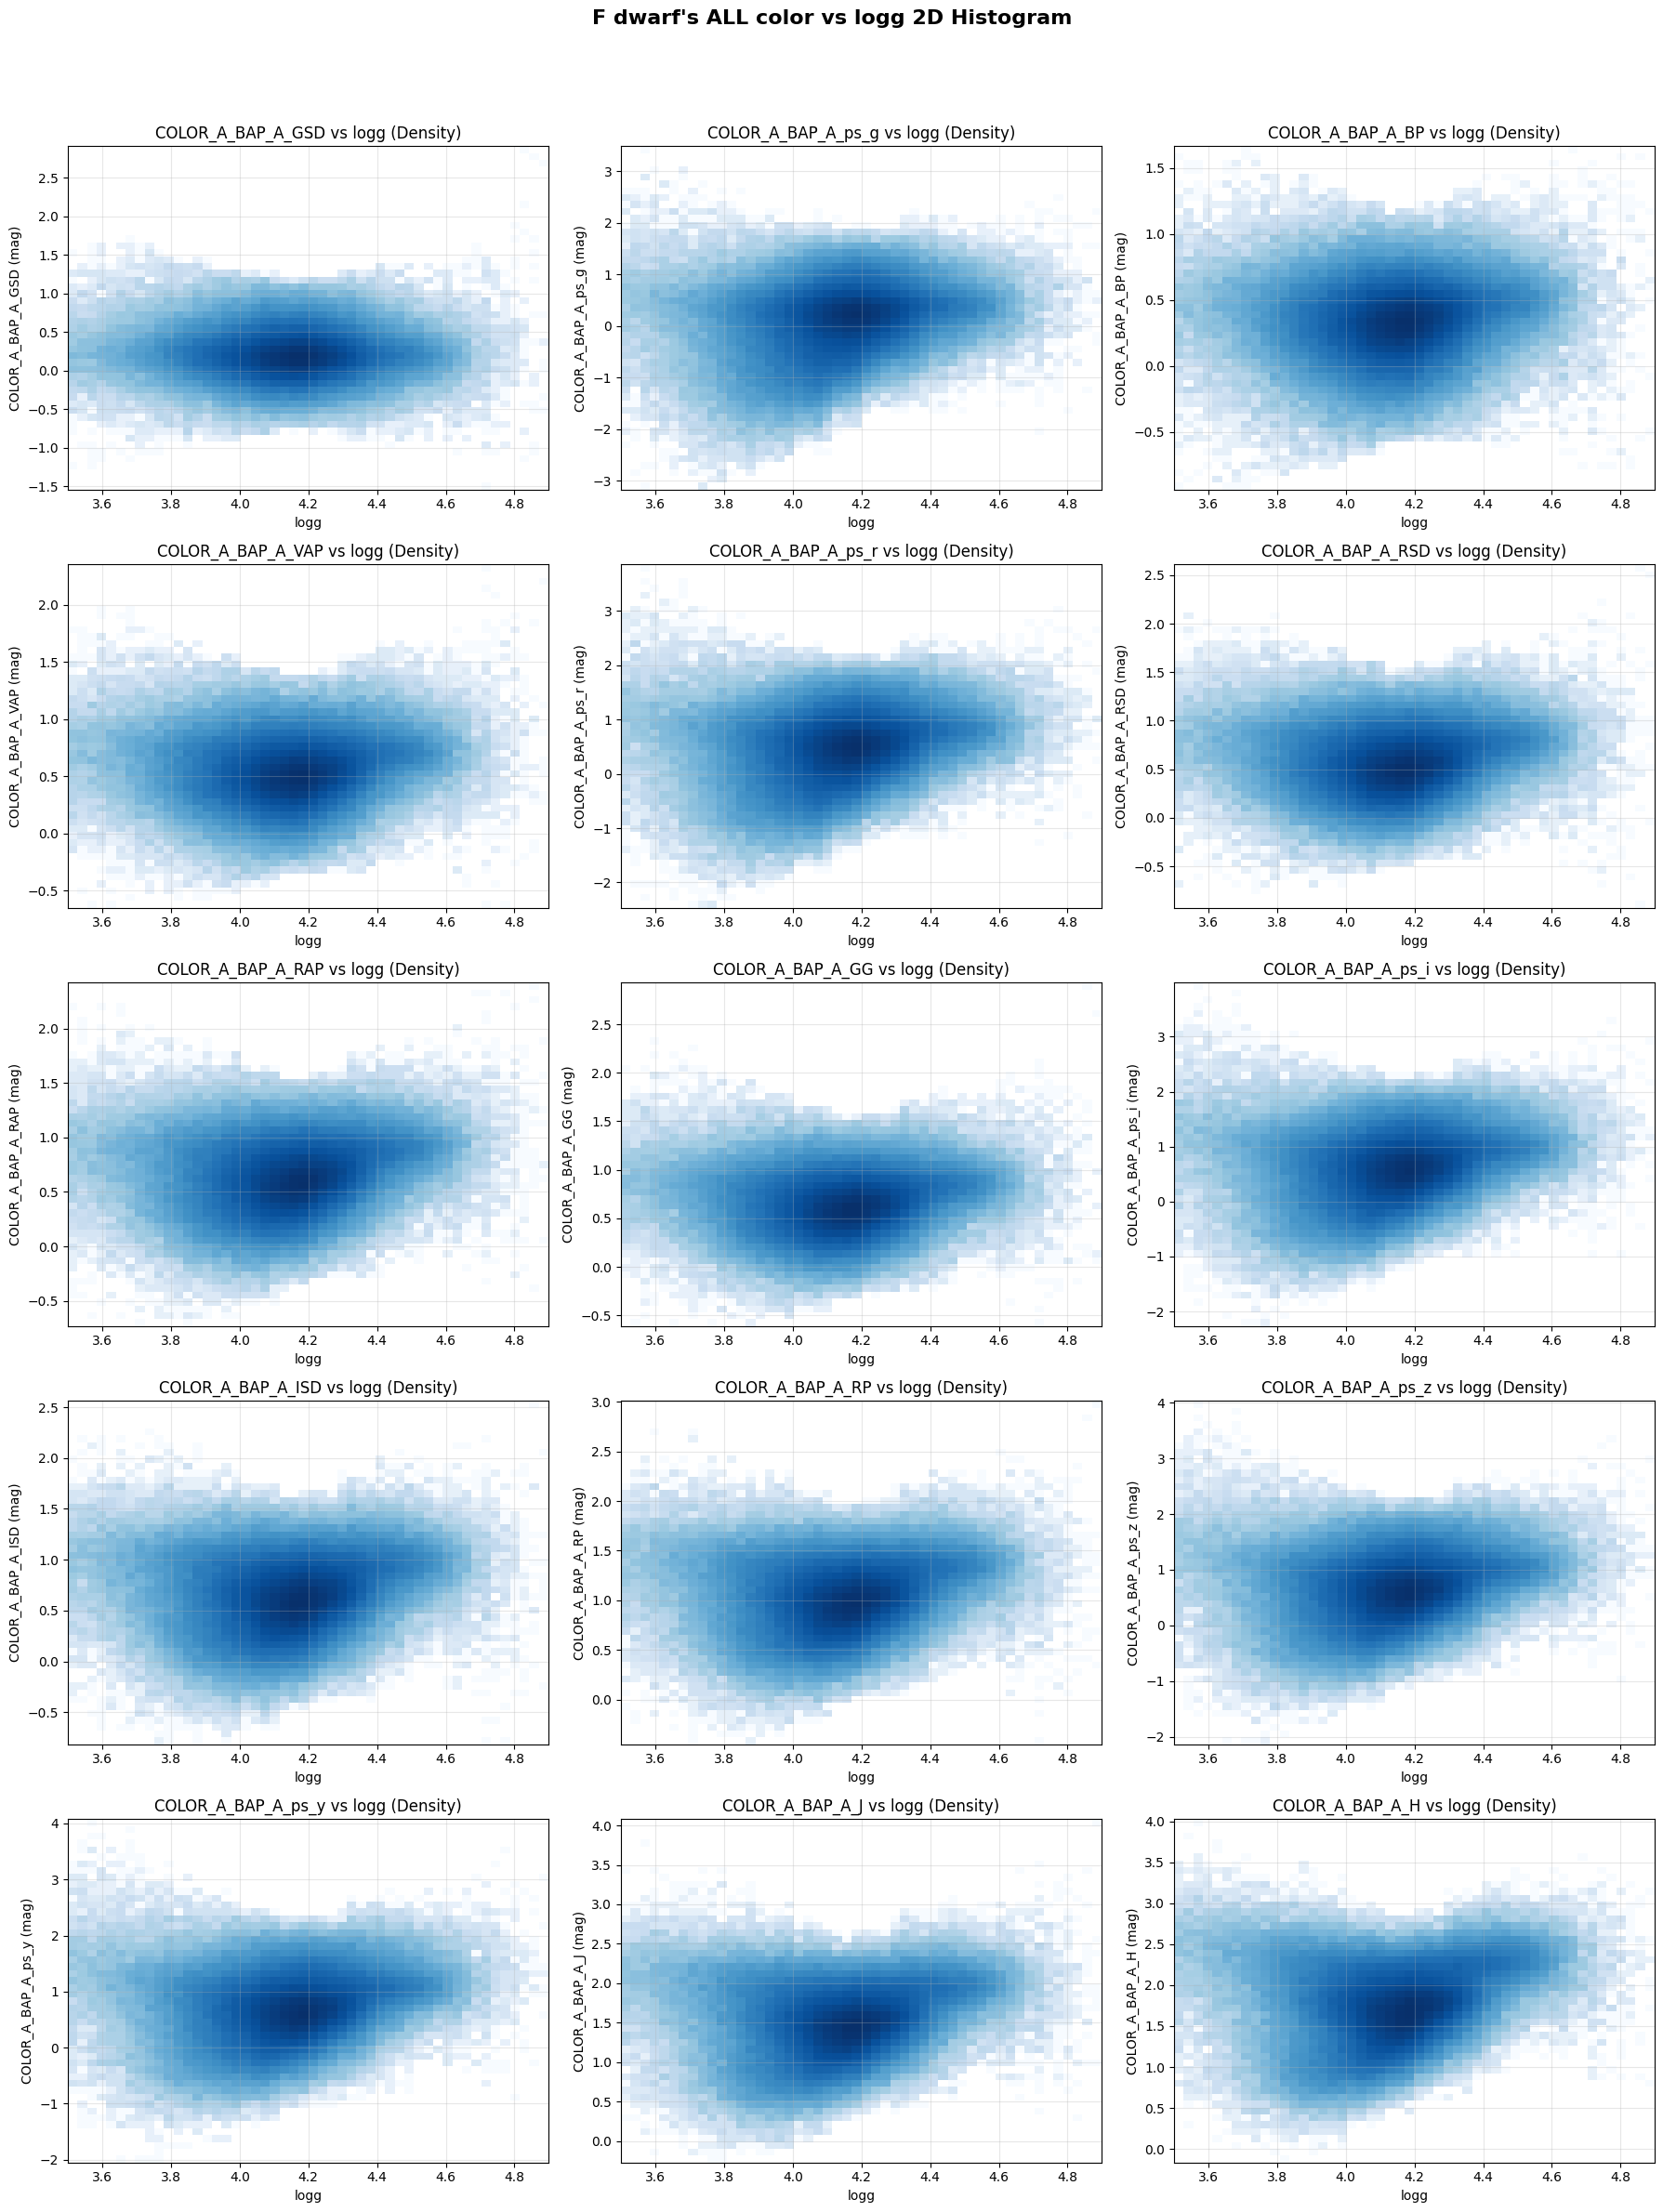

In [19]:
from matplotlib.colors import LogNorm

# 2. ALL color vs logg plots (2D Histograms)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    # Use 2D histogram with log scale to show density
    h = ax.hist2d(df_clean_viz['logg'], df_clean_viz[color_name], 
                  bins=50, cmap='Blues', norm=LogNorm(), cmin=1)
    
    ax.set_xlabel('logg')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs logg (Density)')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("F dwarf's ALL color vs logg 2D Histogram", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_logg_density.png', dpi=150, bbox_inches='tight')
plt.show()

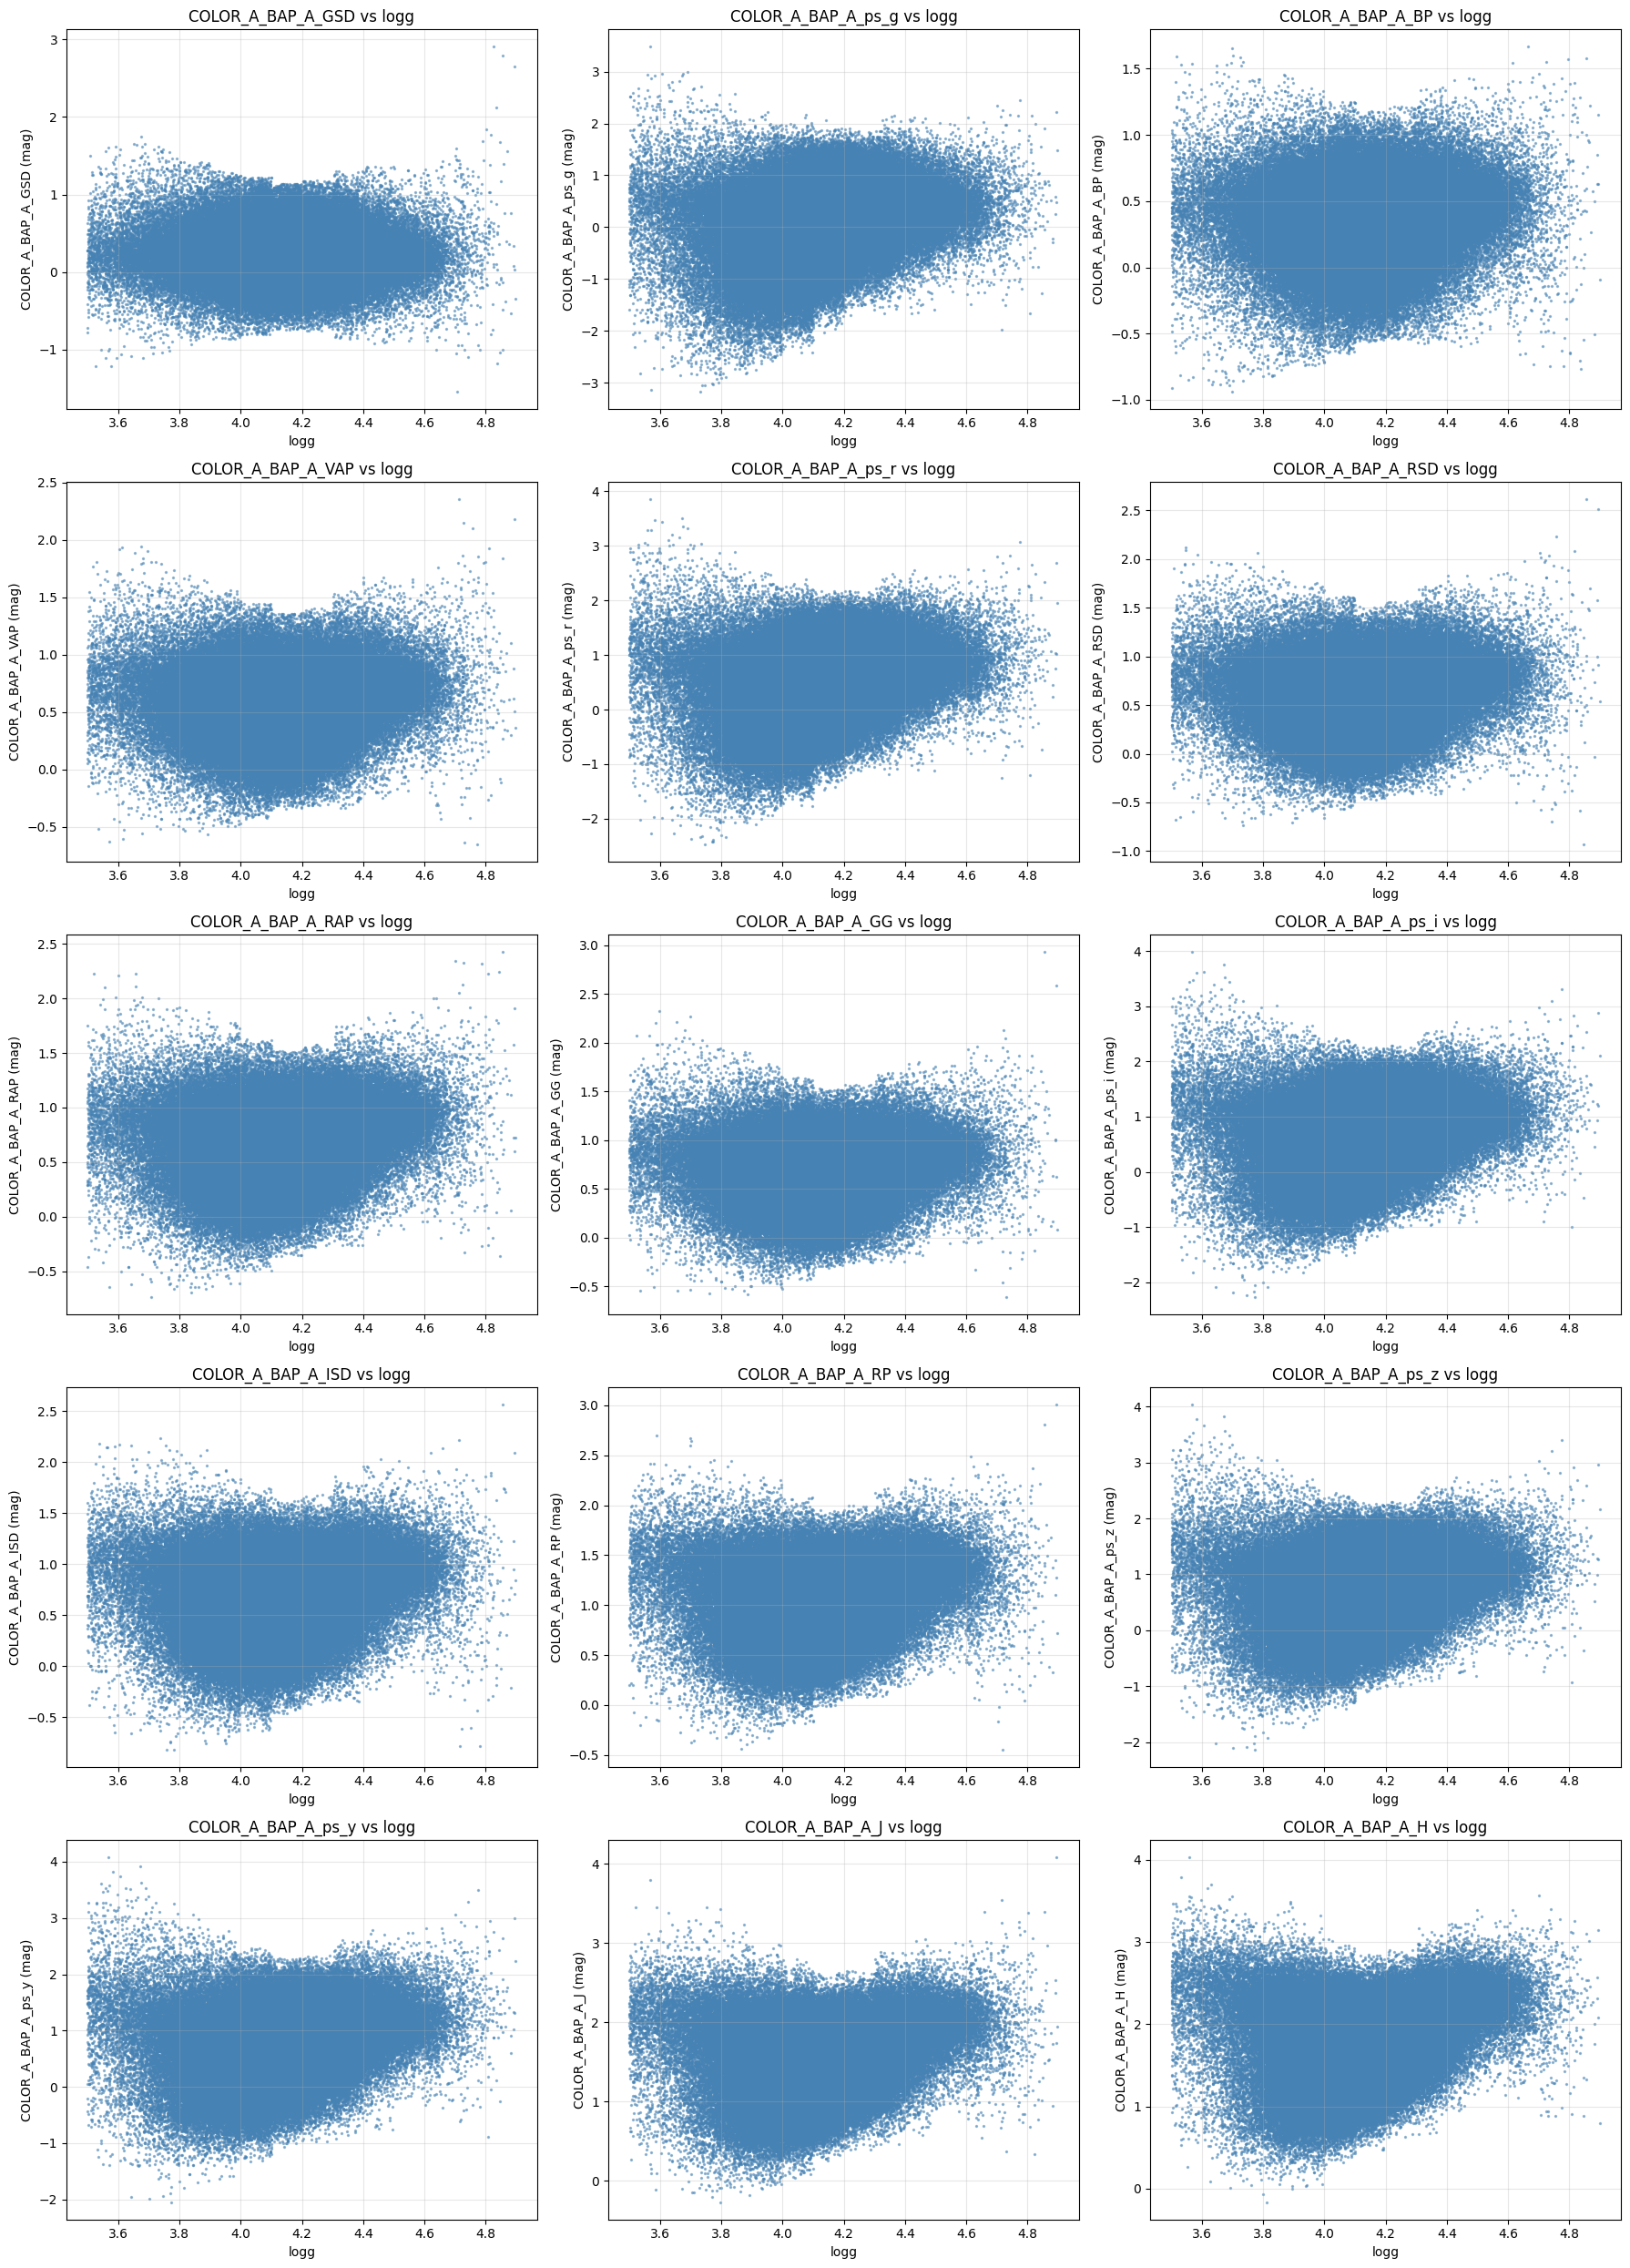

In [20]:
# 2. ALL color vs logg plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, color_name in enumerate(representative_colors):
    ax = axes[i]
    ax.scatter(df_clean_viz['logg'], df_clean_viz[color_name], color='steelblue', alpha=0.5, s=2)
    ax.set_xlabel('logg')
    ax.set_ylabel(f'{color_name} (mag)')
    ax.set_title(f'{color_name} vs logg')
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
#plt.savefig(RESULTS_DIR / 'clean_all_colors_vs_logg.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
"""# 3. Bin-wise plots for ALL colors
print("Generating bin-wise plots for all colors... this may take a moment.")
logg_bins_available = sorted(df_clean_viz['logg_bin'].dropna().unique())
n_bins = len(logg_bins_available)

for color_name in color_combinations.keys():
    n_rows_bin = (n_bins + 2) // 3
    fig, axes = plt.subplots(n_rows_bin, 3, figsize=(18, 5*n_rows_bin), sharex=True)
    axes = axes.flatten()
    
    for i, bin_name in enumerate(logg_bins_available):
        ax = axes[i]
        data = df_clean_viz[df_clean_viz['logg_bin'] == bin_name][color_name].dropna()
        if len(data) > 0:
            ax.hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            mu, sigma = data.mean(), data.std()
            ax.axvline(mu, color='red', label=f'mu={mu:.3f}')
            ax.axvline(mu+sigma, color='orange', linestyle='--', label=f'sigma={sigma:.3f}')
            ax.axvline(mu-sigma, color='orange', linestyle='--')
            ax.set_title(f'{bin_name} (N={len(data)})')
            ax.legend(fontsize='small')
    
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'Bin-wise distributions for {color_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig(RESULTS_DIR / f'clean_{color_name}_bin_distributions.png', dpi=100)
    plt.close() # Close to save memory
print("Done.")"""

'# 3. Bin-wise plots for ALL colors\nprint("Generating bin-wise plots for all colors... this may take a moment.")\nlogg_bins_available = sorted(df_clean_viz[\'logg_bin\'].dropna().unique())\nn_bins = len(logg_bins_available)\n\nfor color_name in color_combinations.keys():\n    n_rows_bin = (n_bins + 2) // 3\n    fig, axes = plt.subplots(n_rows_bin, 3, figsize=(18, 5*n_rows_bin), sharex=True)\n    axes = axes.flatten()\n    \n    for i, bin_name in enumerate(logg_bins_available):\n        ax = axes[i]\n        data = df_clean_viz[df_clean_viz[\'logg_bin\'] == bin_name][color_name].dropna()\n        if len(data) > 0:\n            ax.hist(data, bins=50, alpha=0.7, color=\'steelblue\', edgecolor=\'black\')\n            mu, sigma = data.mean(), data.std()\n            ax.axvline(mu, color=\'red\', label=f\'mu={mu:.3f}\')\n            ax.axvline(mu+sigma, color=\'orange\', linestyle=\'--\', label=f\'sigma={sigma:.3f}\')\n            ax.axvline(mu-sigma, color=\'orange\', linestyle=\'--\')\n 